In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from math import sqrt
import matplotlib.pyplot as plt
import matplotlib.pyplot as pyplot
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
import xgboost as xgb
import statistics as stats
import statsmodels.api as sm
import shap
from matplotlib.dates import DateFormatter
from xgboost import plot_importance, plot_tree, XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
from sklearn.inspection import PartialDependenceDisplay
from statsmodels.tsa.stattools import adfuller

In [ ]:
!pip install pmdarima
from pmdarima.arima import ndiffs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 7.1 MB/s eta 0:00:00


# *Preprocessing* Data

In [ ]:
# Input Data
data = pd.read_csv('/content/(1) Skripsi_Fellita Odelia Wibowo.csv')
data

,Bulan,Suhu,DPM Rata-rata,DPM Maksimum,DPM Minimum
0,01 1999,24.177419,30092.61419,40613.36,9725.40
1,02 1999,23.971429,33898.16893,40363.34,8823.81
2,03 1999,24.280645,32010.34290,40334.69,1194.58
3,04 1999,24.133333,36139.28767,39600.00,19013.41
4,05 1999,23.590323,38292.59323,39589.61,27711.09
...,...,...,...,...,...
322,11 2025,24.950000,30137.76700,42921.25,10830.69
323,12 2025,24.935484,34640.83645,43361.31,6888.92
324,01 2026,24.474194,31986.48355,43070.62,9689.60
325,02 2026,24.553571,34299.91893,42413.89,10800.00


In [ ]:
# Menyiapkan Data
data = data.set_index('Bulan')
data.index = pd.to_datetime(data.index, format = 'mixed')

In [ ]:
# Menampilkan 5 Baris Pertama
print(data.head())

                 Suhu  DPM Rata-rata  DPM Maksimum  DPM Minimum
Bulan                                                          
1999-01-01  24.177419    30092.61419      40613.36      9725.40
1999-02-01  23.971429    33898.16893      40363.34      8823.81
1999-03-01  24.280645    32010.34290      40334.69      1194.58
1999-04-01  24.133333    36139.28767      39600.00     19013.41
1999-05-01  23.590323    38292.59323      39589.61     27711.09


In [ ]:
# Menampilkan Informasi Data
print(data.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 327 entries, 1999-01-01 to 2026-03-01
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suhu           327 non-null    float64
 1   DPM Rata-rata  327 non-null    float64
 2   DPM Maksimum   327 non-null    float64
 3   DPM Minimum    327 non-null    float64
dtypes: float64(4)
memory usage: 12.8 KB
None


In [ ]:
# Mendefinisikan Variabel
Suhu = data['Suhu']
DPM_mean = data['DPM Rata-rata']
DPM_max = data['DPM Maksimum']
DPM_min = data['DPM Minimum']

# Visualisasi Data

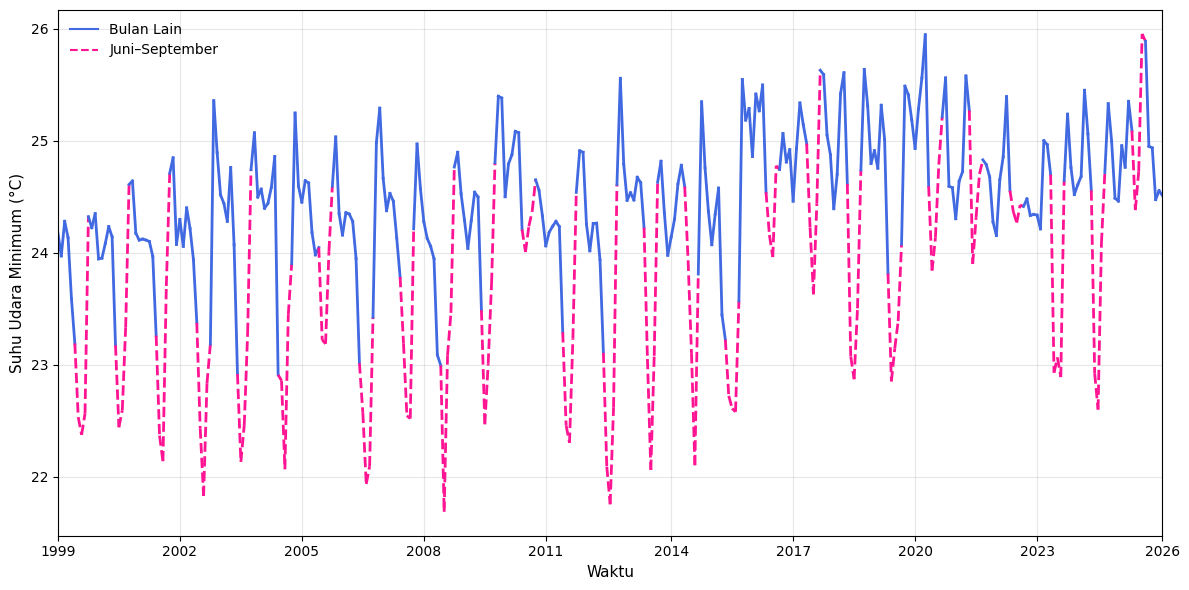

In [ ]:
# Plot Data Suhu (Highlight Bulan Juni-September)
x = np.arange(len(Suhu))
y = Suhu.values.flatten()
bulan = Suhu.index.month

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis = 1)

colors = ['deeppink' if m in [6, 7, 8, 9] else 'royalblue' for m in bulan[:-1]]
linestyles = ['--' if m in [6, 7, 8, 9] else '-' for m in bulan[:-1]]

fig, ax = plt.subplots(figsize = (12, 6))
for seg, c, ls in zip(segments, colors, linestyles):
    ax.plot(seg[:,0], seg[:,1], color = c, linestyle = ls, linewidth = 2)

ax.set_xlim(x.min(), x.max())
ax.set_xlabel("Waktu", fontsize = 11)
ax.set_ylabel("Suhu Udara Minimum (°C)", fontsize = 11)

xticks = np.linspace(0, len(Suhu)-1, 10, dtype = int)
ax.set_xticks(xticks)
ax.set_xticklabels(pd.to_datetime(Suhu.index[xticks]).year, rotation = 0)

ax.grid(alpha = 0.3)
ax.plot([], [], color = 'royalblue', linestyle = '-', label = 'Bulan Lain')
ax.plot([], [], color = 'deeppink', linestyle = '--', label = 'Juni–September')
ax.legend(loc = 'upper left', frameon = False)

plt.tight_layout()
plt.show()

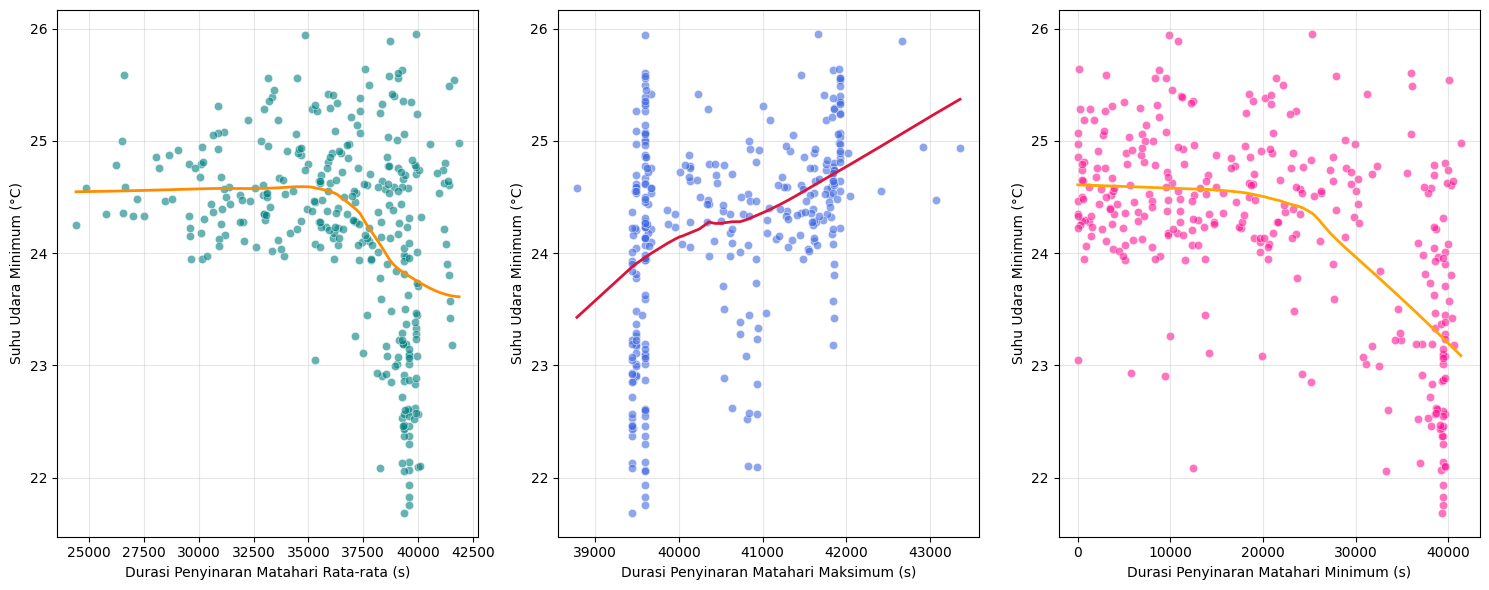

In [ ]:
# Plot Durasi Penyinaran Matahari dengan Suhu
plt.figure(figsize = (15, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x = 'DPM Rata-rata', y = 'Suhu', data = data,
                color = 'teal', alpha = 0.6)
sns.regplot(x = 'DPM Rata-rata', y = 'Suhu', data = data,
            scatter = False, lowess = True, color = 'darkorange', line_kws = {'linewidth': 2})
plt.xlabel('Durasi Penyinaran Matahari Rata-rata (s)')
plt.ylabel('Suhu Udara Minimum (°C)')
plt.grid(alpha = 0.3)

plt.subplot(1, 3, 2)
sns.scatterplot(x = 'DPM Maksimum', y = 'Suhu', data = data,
                color = 'royalblue', alpha = 0.6)
sns.regplot(x = 'DPM Maksimum', y = 'Suhu', data = data,
            scatter = False, lowess = True, color = 'crimson', line_kws = {'linewidth': 2})
plt.xlabel('Durasi Penyinaran Matahari Maksimum (s)')
plt.ylabel('Suhu Udara Minimum (°C)')
plt.grid(alpha = 0.3)

plt.subplot(1, 3, 3)
sns.scatterplot(x = 'DPM Minimum', y = 'Suhu', data = data,
                color = 'deeppink', alpha = 0.6)
sns.regplot(x = 'DPM Minimum', y = 'Suhu', data = data,
            scatter = False, lowess = True, color = 'orange', line_kws = {'linewidth': 2})
plt.xlabel('Durasi Penyinaran Matahari Minimum (s)')
plt.ylabel('Suhu Udara Minimum (°C)')
plt.grid(alpha = 0.3)

plt.tight_layout()
plt.show()

# Karakteristik Data

In [ ]:
# Uji Stasioneritas (Uji Augmented Dickey-Fuller, ADF)
adf_result = adfuller(Suhu.dropna(), maxlag = 6, autolag = None)

print(f"ADF Statistic : {adf_result[0]}")
print(f"p-value       : {adf_result[1]}")
print(f"Lag used      : {adf_result[2]}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key} : {value}")

if adf_result[1] < 0.05:
    print("Tolak H0: Data Stasioner")
else:
    print("Terima H0: Data Tidak Stasioner")

ADF Statistic : -7.427135265590935
p-value       : 6.503926261025123e-11
Lag used      : 6
Critical Values:
   1% : -3.450951662384033
   5% : -2.8706147570800784
   10% : -2.571604931640625
Tolak H0: Data Stasioner


In [ ]:
# Penentuan Orde Differencing (d)
d = ndiffs(Suhu, test = 'adf')
print("Nilai d:", d)

Nilai d: 0


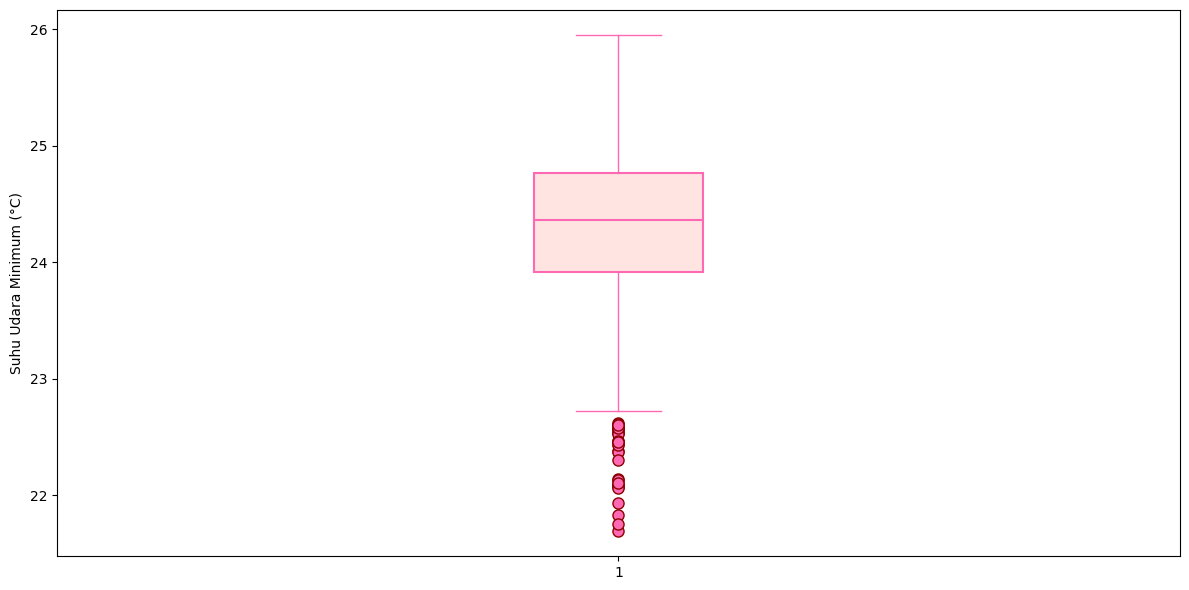

In [ ]:
# Boxplot
plt.figure(figsize = (12, 6), facecolor = 'white')

box = plt.boxplot(Suhu, patch_artist = True,
                  boxprops = dict(facecolor = 'mistyrose',
                              color = 'hotpink',
                              linewidth = 1.5),
                  whiskerprops = dict(color = 'hotpink', linewidth = 1),
                  capprops = dict(color = 'hotpink', linewidth = 1),
                  medianprops = dict(color = 'hotpink', linewidth = 1.5),
                  flierprops = dict(marker = 'o',
                                markerfacecolor = 'hotpink',
                                markeredgecolor = 'darkred',
                                markeredgewidth = 1,
                                markersize = 8))

plt.ylabel("Suhu Udara Minimum (°C)")
plt.tight_layout()
plt.show()

In [ ]:
# Mendeteksi Outliers
Q1_suhu = Suhu.quantile(0.25)
Q3_suhu = Suhu.quantile(0.75)
IQR_suhu = Q3_suhu - Q1_suhu
lower_bound_suhu = Q1_suhu - 1.5 * IQR_suhu
upper_bound_suhu = Q3_suhu + 1.5 * IQR_suhu
outliers_suhu = Suhu[(Suhu < lower_bound_suhu) | (Suhu > upper_bound_suhu)]
print("Outliers:\n", outliers_suhu)

Outliers:
 Bulan
1999-07-01    22.532258
1999-08-01    22.374194
1999-09-01    22.563333
2000-07-01    22.441935
2000-08-01    22.593548
2001-07-01    22.367742
2001-08-01    22.138710
2002-07-01    22.432258
2002-08-01    21.829032
2003-07-01    22.132258
2003-08-01    22.461290
2004-08-01    22.067742
2006-07-01    22.570968
2006-08-01    21.935484
2006-09-01    22.093333
2007-08-01    22.545161
2007-09-01    22.520000
2008-07-01    21.687097
2009-07-01    22.467742
2011-07-01    22.458065
2011-08-01    22.303226
2012-07-01    22.090323
2012-08-01    21.754839
2012-09-01    22.620000
2013-08-01    22.061290
2014-09-01    22.103333
2015-08-01    22.609677
2015-09-01    22.580000
2024-08-01    22.600000
Name: Suhu, dtype: float64


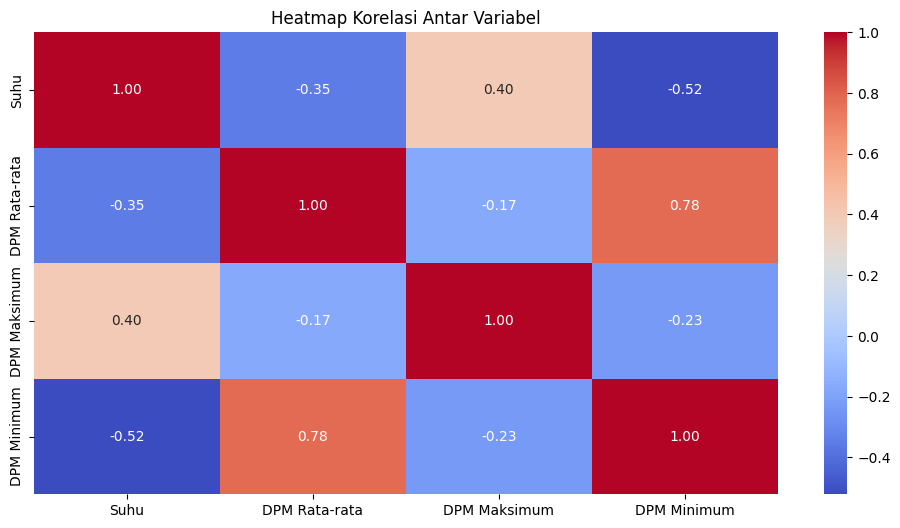

In [ ]:
# Mengidentifikasi Korelasi Antar Variabel
corr_matrix = data.corr()
plt.figure(figsize = (12, 6))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Heatmap Korelasi Antar Variabel")
plt.show()

# Model XGBoost

In [ ]:
# Fitur Time Series
def create_features(data, target, lag_features, exog_features, lag_exogs, rolling_windows):
    # Salinan DataFrame (menghindari modifikasi data asli)
    data_features = data.copy()
    # Date-Time
    data_features['month'] = data_features.index.month
    data_features['year'] = data_features.index.year
    # Lag Features untuk Variabel Target (berbasis bulanan)
    for lag in lag_features:
        data_features[f'{target}_lag_{lag}'] = data_features[target].shift(lag)
    # Lag Features untuk Variabel Eksogen (berbasis bulanan)
    for feature in exog_features:
        for lag in lag_exogs:
            data_features[f'{feature}_lag_{lag}'] = data_features[feature].shift(lag)
    # Rolling Windows
    for col in data.columns:
        for window in rolling_windows:
            data_features[f'{col}_mean_{window}'] = (data_features[col].shift(1).rolling(window = window).mean())
            data_features[f'{col}_std_{window}'] = (data_features[col].shift(1).rolling(window = window).std())
    # Cyclical Encoding
    data_features['month_sin'] = np.sin(2 * np.pi * data_features['month']/12)
    data_features['month_cos'] = np.cos(2 * np.pi * data_features['month']/12)

    # Hapus baris dengan nilai NaN (yang dihasilkan dari shift dan rolling)
    data_features.dropna(inplace = True)

    return data_features

In [ ]:
# Mendefinisikan Fitur
target = 'Suhu'
lag_features = [6, 12, 24]
exog_features = ['DPM Rata-rata', 'DPM Maksimum', 'DPM Minimum']
lag_exogs = [6, 12, 24]
rolling_windows = [6, 12, 24]

In [ ]:
# Split Data Hasil Feature Engineering X & y
processed = create_features(data, target, lag_features, exog_features, lag_exogs, rolling_windows)

X = processed.drop(target, axis = 1)
y = processed[target]

print(f"X: {X.shape}")
print(f"y: {y.shape}")

X: (303, 43)
y: (303,)


In [ ]:
# Mengidentifikasi Parameter Terbaik
best_params = {
    "max_depth": 3,
    "learning_rate": 0.05,
    "n_estimators": 300,
    "subsample": 0.8,
    "colsample_bytree": 0.7,
    "min_child_weight": 10,
    "gamma": 1,
    "reg_alpha": 2,
    "reg_lambda": 5
    }

In [ ]:
# Model Data dengan Parameter Terbaik
final_model = xgb.XGBRegressor(**best_params, n_jobs = -1, objective = 'reg:squarederror')
final_model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# Membuat Prediksi pada Data
y_pred = final_model.predict(X)

# Feature Importance

In [ ]:
# Feature Importance dari Model
importance = final_model.feature_importances_
feature_names = X.columns

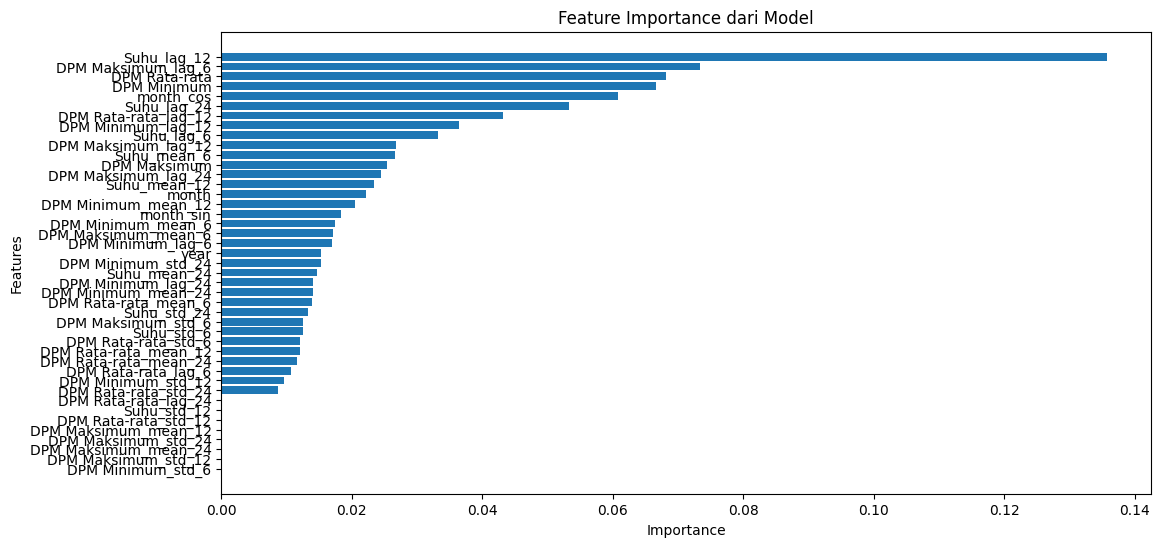

In [ ]:
# Visualisasi Feature Importance dari Model
feature_importance_data = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
})

feature_importance_data = feature_importance_data.sort_values(by = 'importance', ascending = False)

plt.figure(figsize = (12, 6))
plt.barh(feature_importance_data['feature'], feature_importance_data['importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance dari Model')
plt.gca().invert_yaxis()
plt.show()

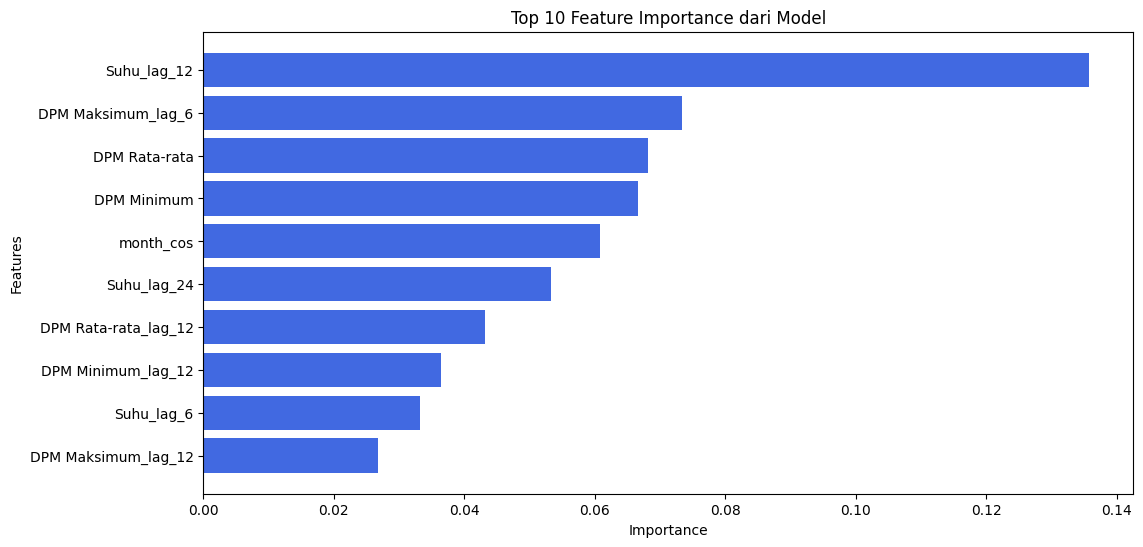

In [ ]:
# Visualisasi Feature Importance dari Model (10 Teratas)
feature_importance_data = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
})

feature_importance_data = feature_importance_data.sort_values(by = 'importance', ascending = False)

top_10_features = feature_importance_data.head(10)

plt.figure(figsize = (12, 6))
plt.barh(top_10_features['feature'], top_10_features['importance'], color = 'royalblue')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Top 10 Feature Importance dari Model')
plt.gca().invert_yaxis()
plt.show()

# Evaluasi Model

In [ ]:
# Fungsi MAPE
def mean_absolute_percentage_error(y_true, y_pred):

    y_true, y_pred = np.array(y_true), np.array(y_pred)

    ape = np.abs((y_true - y_pred) / y_true)

    mape = np.mean(ape) * 100

    return mape

In [ ]:
# Evaluasi
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y, y_pred)

print("Evaluasi:")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.3f}%")

Evaluasi:
MSE: 0.125
RMSE: 0.354
MAPE: 1.163%


# Analisis SHAP (TreeSHAP)

In [ ]:
# Explainer SHAP
explainer = shap.TreeExplainer(final_model)

In [ ]:
# Nilai SHAP pada Semua Data Test
shap_values_all = explainer.shap_values(X)

shap_values_all_df = pd.DataFrame(shap_values_all, columns = X.columns)
shap_values_all_df

,DPM Rata-rata,DPM Maksimum,DPM Minimum,month,year,Suhu_lag_6,Suhu_lag_12,Suhu_lag_24,DPM Rata-rata_lag_6,DPM Rata-rata_lag_12,...,DPM Maksimum_mean_24,DPM Maksimum_std_24,DPM Minimum_mean_6,DPM Minimum_std_6,DPM Minimum_mean_12,DPM Minimum_std_12,DPM Minimum_mean_24,DPM Minimum_std_24,month_sin,month_cos
0,0.031420,0.048651,0.124771,-0.029346,-0.066628,-0.031928,-0.158731,-0.024490,0.010625,0.040243,...,0.0,0.0,0.005105,0.0,0.000660,0.003463,0.009813,-0.003139,0.003082,0.017938
1,0.031420,0.038979,0.125624,-0.029346,-0.076328,-0.032243,-0.154675,-0.024490,0.010625,0.037441,...,0.0,0.0,-0.011114,0.0,0.000660,0.003463,0.009813,-0.003139,0.003082,0.017938
2,-0.002282,0.000495,0.123893,-0.029346,-0.080850,-0.019490,0.010571,-0.025769,0.008260,0.038796,...,0.0,0.0,-0.011114,0.0,0.002237,0.003463,0.011977,-0.002899,0.003082,0.017938
3,0.033436,-0.002148,0.134683,0.013110,-0.078278,0.009759,0.001852,-0.035915,0.006943,0.031347,...,0.0,0.0,-0.011114,0.0,0.002237,0.003463,0.011977,-0.001297,0.003082,-0.008559
4,-0.055821,-0.029796,-0.359071,0.002014,-0.054558,0.076279,-0.044645,-0.036434,-0.001238,0.013532,...,0.0,0.0,-0.009084,0.0,0.002237,0.003609,0.011977,-0.001297,0.003082,-0.008323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.007037,0.085957,0.099111,0.025415,0.081538,0.052516,0.299893,0.025126,-0.006006,-0.003293,...,0.0,0.0,-0.003595,0.0,-0.002813,-0.011684,0.011322,0.006204,-0.002880,0.002097
299,0.015668,0.092290,0.078371,0.025415,0.072773,0.052208,0.276447,0.025126,-0.001522,0.018860,...,0.0,0.0,-0.003595,0.0,-0.002813,-0.011684,-0.010211,0.006204,0.003082,0.002097
300,0.016426,0.088734,0.101969,-0.034500,0.078773,-0.033270,0.097721,-0.009372,0.005003,0.027071,...,0.0,0.0,-0.004173,0.0,-0.009538,-0.011684,-0.007295,0.006204,0.003082,0.002097
301,0.020771,0.096529,0.107525,-0.028310,0.072900,0.044100,-0.014507,0.016362,0.002964,0.019623,...,0.0,0.0,-0.003595,0.0,-0.009538,-0.011684,-0.008047,0.006204,0.003082,0.002097


In [ ]:
# Ranking Fitur Global
mean_abs_shap_all = np.abs(shap_values_all).mean(axis = 0)

feature_importance_all = pd.DataFrame({
    'feature': X.columns,
    'mean_abs_shap': mean_abs_shap_all
}).sort_values(by = 'mean_abs_shap', ascending = False)

print("Ranking Fitur (Global):")
print(feature_importance_all)

Ranking Fitur (Global):
                  feature  mean_abs_shap
6             Suhu_lag_12       0.234122
2             DPM Minimum       0.159375
17            Suhu_mean_6       0.085221
4                    year       0.062473
1            DPM Maksimum       0.058021
5              Suhu_lag_6       0.051779
15     DPM Minimum_lag_12       0.033278
9    DPM Rata-rata_lag_12       0.029808
23   DPM Rata-rata_mean_6       0.027661
0           DPM Rata-rata       0.025931
12    DPM Maksimum_lag_12       0.024936
7             Suhu_lag_24       0.024310
19           Suhu_mean_12       0.019929
22            Suhu_std_24       0.019573
3                   month       0.018187
29    DPM Maksimum_mean_6       0.017530
11     DPM Maksimum_lag_6       0.013913
24    DPM Rata-rata_std_6       0.013089
39    DPM Minimum_mean_24       0.012896
25  DPM Rata-rata_mean_12       0.012271
13    DPM Maksimum_lag_24       0.012197
35     DPM Minimum_mean_6       0.008196
8     DPM Rata-rata_lag_6       0

In [ ]:
# Filter Data Bulan Juni-September
X_js = X[X['month'].isin([6, 7, 8, 9])]
shap_values_js = explainer.shap_values(X_js)

In [ ]:
# 5 Fitur Teratas
top5_features = feature_importance_all.head(5)['feature'].tolist()
print("5 Fitur Teratas Global:", top5_features)

5 Fitur Teratas Global: ['Suhu_lag_12', 'DPM Minimum', 'Suhu_mean_6', 'year', 'DPM Maksimum']


In [ ]:
# Nilai SHAP pada Bulan Juni–September
shap_values_js_df = pd.DataFrame(shap_values_js, columns = X_js.columns)
shap_values_js_df

,DPM Rata-rata,DPM Maksimum,DPM Minimum,month,year,Suhu_lag_6,Suhu_lag_12,Suhu_lag_24,DPM Rata-rata_lag_6,DPM Rata-rata_lag_12,...,DPM Maksimum_mean_24,DPM Maksimum_std_24,DPM Minimum_mean_6,DPM Minimum_std_6,DPM Minimum_mean_12,DPM Minimum_std_12,DPM Minimum_mean_24,DPM Minimum_std_24,month_sin,month_cos
0,0.036352,-0.148583,0.136340,0.006831,-0.060185,-0.058070,-0.522784,-0.036434,0.010625,-0.009806,...,0.0,0.0,-0.011114,0.0,0.000660,-0.001135,0.008674,-0.003139,0.003082,-0.002015
1,-0.036976,-0.112611,-0.316811,-0.000231,-0.043504,-0.085819,-0.570363,-0.036434,-0.016551,-0.052014,...,0.0,0.0,-0.009084,0.0,0.000660,0.000640,0.008674,-0.006291,-0.006257,-0.009492
2,-0.045116,-0.043180,-0.389858,0.002014,-0.047177,-0.087703,-0.560750,-0.036434,-0.016551,-0.052014,...,0.0,0.0,-0.009084,0.0,0.000660,0.001416,0.008674,-0.006291,-0.006257,-0.008323
3,-0.045116,0.003430,-0.357976,0.002014,-0.040186,-0.076023,-0.432141,-0.029320,0.008355,-0.043576,...,0.0,0.0,0.012048,0.0,0.000660,0.001416,0.008674,-0.003139,-0.006257,-0.008323
4,-0.036976,-0.091135,-0.246968,0.000371,-0.048232,-0.070109,-0.503054,-0.036434,-0.006634,0.054060,...,0.0,0.0,-0.009084,0.0,0.000660,0.002833,0.008674,-0.003139,0.003082,-0.006217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,-0.051556,0.009339,-0.203679,0.004919,0.057839,0.149978,-0.454061,0.001560,-0.006917,-0.039587,...,0.0,0.0,-0.009084,0.0,0.000660,-0.001332,-0.004927,0.012842,-0.006257,-0.002551
96,0.024829,-0.128403,0.106709,0.009906,0.086357,0.065943,0.137321,0.032337,-0.006006,-0.013250,...,0.0,0.0,-0.003595,0.0,0.002237,0.003440,0.027207,0.004118,0.003082,0.004825
97,-0.001589,0.019666,0.130584,0.011795,0.068460,-0.066209,-0.448626,-0.021204,-0.013784,-0.020560,...,0.0,0.0,-0.004173,0.0,0.000660,0.003440,0.018482,0.010756,-0.006257,-0.002943
98,0.002696,0.019418,0.166000,0.014146,0.077115,-0.068498,-0.437062,-0.021204,-0.005687,-0.032122,...,0.0,0.0,-0.004173,0.0,0.000660,-0.001142,0.018482,0.012842,-0.006257,-0.002943


In [ ]:
# Rata-rata Nilai SHAP (Juni-September)
mean_shap_js_signed = shap_values_js.mean(axis = 0)

mean_abs_shap_js = np.abs(mean_shap_js_signed) # nilai absolutnya untuk ranking

shap_js_df = pd.DataFrame({
    'feature': X_js.columns,
    'mean_SHAP_signed_JS': mean_shap_js_signed,
    'abs_SHAP': mean_abs_shap_js
})

shap_js_top5 = shap_js_df[shap_js_df['feature'].isin(top5_features)] # filter 5 fitur global
shap_js_top5 = shap_js_top5.sort_values(by = 'abs_SHAP', ascending = False) # urutkan berdasarkan absolut

shap_js_top5[['feature','mean_SHAP_signed_JS']].style.format({
    'mean_SHAP_signed_JS': "{:.3f}"
})

,feature,mean_SHAP_signed_JS
6,Suhu_lag_12,-0.313
2,DPM Minimum,-0.157
1,DPM Maksimum,-0.072
17,Suhu_mean_6,0.014
4,year,-0.001


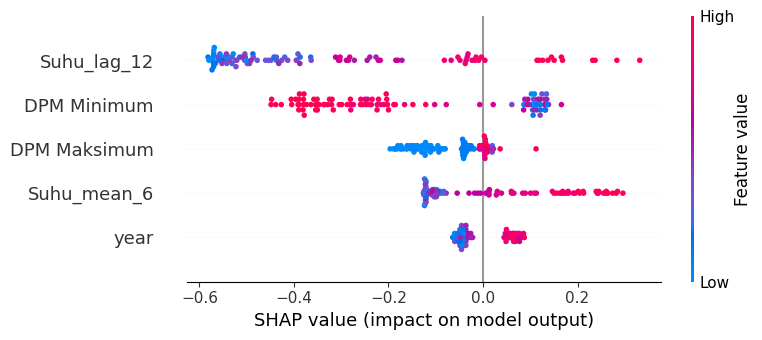

In [ ]:
# Visualisasi Nilai SHAP Bulan Juni–September (Beeswarm Plot)
mean_shap_js_signed = shap_values_js.mean(axis = 0)

shap_js_df = pd.DataFrame({
    'feature': X_js.columns,
    'mean_SHAP_signed_JS': mean_shap_js_signed
})

shap_js_top5 = shap_js_df[shap_js_df['feature'].isin(top5_features)].copy()

shap_js_top5['abs_SHAP'] = shap_js_top5['mean_SHAP_signed_JS'].abs()
shap_js_top5 = shap_js_top5.sort_values(by = 'abs_SHAP', ascending = False)

ordered_features = shap_js_top5['feature'].tolist() # urutan fitur sesuai tabel final

X_js_top5 = X_js[ordered_features] # subset data dan SHAP sesuai urutan tersebut
top5_indices = [X_js.columns.get_loc(f) for f in ordered_features]
shap_values_js_top5 = shap_values_js[:, top5_indices]

shap.summary_plot( # beeswarm plot
    shap_values_js_top5,
    X_js_top5,
    sort = False
)

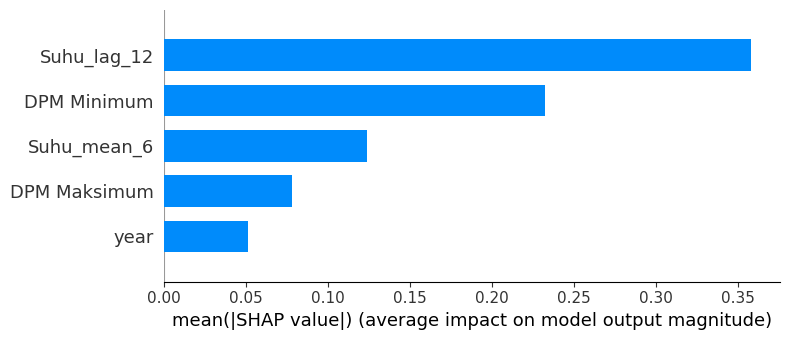

In [ ]:
# Visualisasi Nilai SHAP Bulan Juni–September (Bar Plot Importance)
shap.summary_plot(shap_values_js_top5, X_js_top5, plot_type = "bar")

# Data Aktual vs Prediksi

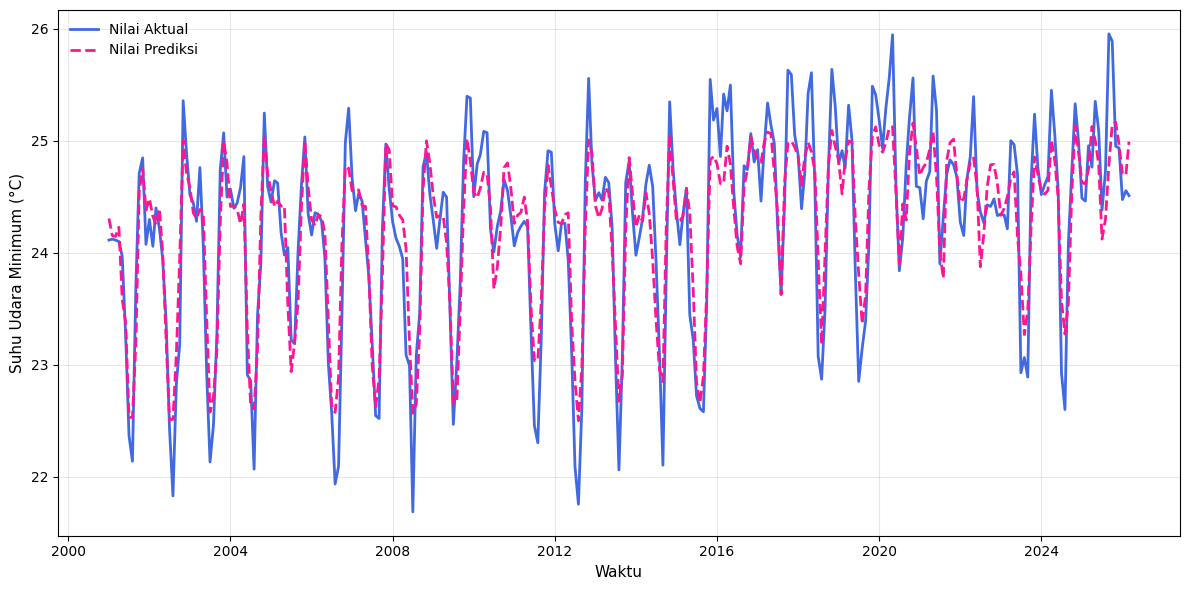

In [ ]:
# Visualisasi Data Aktual vs Prediksi
hasil = pd.DataFrame({
    'aktual': y,
    'prediksi': y_pred
})

plt.figure(figsize = (12, 6))

plt.plot(
    hasil.index,
    hasil['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    hasil.index,
    hasil['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

plt.xlabel('Waktu', fontsize = 11)
plt.ylabel('Suhu Udara Minimum (°C)', fontsize = 11)

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

In [ ]:
# Data Aktual, Prediksi, dan Selisih
print("\n  Aktual   |  Prediksi  |  Selisih")
print("-" * 45)
for aktual, prediksi in zip(y, y_pred):
    selisih = aktual - prediksi
    print(f"  {aktual:.3f}         {prediksi:.3f}            {selisih:.3f}")


  Aktual   |  Prediksi  |  Selisih
---------------------------------------------
  24.113         24.305            -0.192
  24.121         24.153            -0.032
  24.113         24.145            -0.032
  24.100         24.227            -0.127
  23.968         23.585            0.382
  23.260         23.375            -0.115
  22.368         22.529            -0.162
  22.139         22.531            -0.392
  23.703         23.199            0.504
  24.710         24.545            0.165
  24.847         24.756            0.091
  24.074         24.380            -0.306
  24.297         24.482            -0.186
  24.057         24.325            -0.268
  24.400         24.250            0.150
  24.217         24.394            -0.177
  23.939         23.991            -0.053
  23.373         23.205            0.168
  22.432         22.509            -0.076
  21.829         22.513            -0.684
  22.833         23.104            -0.271
  23.184         23.958            -0.774


# Peramalan

In [ ]:
# Index Waktu Forecast (9 Bulan ke Depan)
forecast_index = pd.date_range(start = '2026-04-01', periods = 9, freq = 'MS')

In [ ]:
# Hasil Forecast Durasi Penyinaran Matahari Univariat

forecast_dpm_mean = pd.Series(  # DPM Rata-rata
    [36409.082, 37328.203, 38158.410,
     38807.402, 39187.352, 39407.031,
     39360.770, 36900.164, 35442.367],
    index = forecast_index,
    name = 'DPM Rata-rata'
)

forecast_dpm_max = pd.Series(  # DPM Maksimum
    [40162.660, 40140.383, 40121.953,
     40111.316, 40023.516, 41305.148,
     41894.172, 41941.258, 41902.547],
    index = forecast_index,
    name = 'DPM Maksimum'
)

forecast_dpm_min = pd.Series(  # DPM Minimum
    [18815.248, 16587.387, 20925.971,
     19378.189, 21412.773, 19168.076,
     15216.311, 11547.577, 11261.506],
    index = forecast_index,
    name = 'DPM Minimum'
)

forecast_dpm = pd.concat(
    [forecast_dpm_mean, forecast_dpm_max, forecast_dpm_min],
    axis = 1
)

print(forecast_dpm)

            DPM Rata-rata  DPM Maksimum  DPM Minimum
2026-04-01      36409.082     40162.660    18815.248
2026-05-01      37328.203     40140.383    16587.387
2026-06-01      38158.410     40121.953    20925.971
2026-07-01      38807.402     40111.316    19378.189
2026-08-01      39187.352     40023.516    21412.773
2026-09-01      39407.031     41305.148    19168.076
2026-10-01      39360.770     41894.172    15216.311
2026-11-01      36900.164     41941.258    11547.577
2026-12-01      35442.367     41902.547    11261.506


In [ ]:
# Menyiapkan Data untuk Forecast Suhu (9 Bulan ke Depan)
last_historical_data = processed.iloc[[-1]].copy()

forecast_data = pd.DataFrame(index = forecast_index)
forecast_data['Suhu'] = np.nan
for feature in exog_features:
    forecast_data[feature] = forecast_dpm[feature]
print(forecast_data)

            Suhu  DPM Rata-rata  DPM Maksimum  DPM Minimum
2026-04-01   NaN      36409.082     40162.660    18815.248
2026-05-01   NaN      37328.203     40140.383    16587.387
2026-06-01   NaN      38158.410     40121.953    20925.971
2026-07-01   NaN      38807.402     40111.316    19378.189
2026-08-01   NaN      39187.352     40023.516    21412.773
2026-09-01   NaN      39407.031     41305.148    19168.076
2026-10-01   NaN      39360.770     41894.172    15216.311
2026-11-01   NaN      36900.164     41941.258    11547.577
2026-12-01   NaN      35442.367     41902.547    11261.506


In [ ]:
# Iterative Forecasting untuk 9 Bulan ke Depan
historical_features = X.columns.tolist()
forecast_results = []

last_row = processed.iloc[[-1]].copy()
current_features = last_row[historical_features].copy()

temp_history = data['Suhu'].tolist()
dpm_mean_history = data['DPM Rata-rata'].tolist()
dpm_max_history = data['DPM Maksimum'].tolist()
dpm_min_history = data['DPM Minimum'].tolist()

for i in range(len(forecast_index)):

    suhu_pred = final_model.predict(current_features)[0]
    forecast_results.append(suhu_pred)

    temp_history.append(suhu_pred)
    dpm_mean_history.append(forecast_dpm.iloc[i]['DPM Rata-rata'])
    dpm_max_history.append(forecast_dpm.iloc[i]['DPM Maksimum'])
    dpm_min_history.append(forecast_dpm.iloc[i]['DPM Minimum'])

    if i < len(forecast_index) - 1:
        temp_df = pd.DataFrame({
            'Suhu': temp_history,
            'DPM Rata-rata': dpm_mean_history,
            'DPM Maksimum': dpm_max_history,
            'DPM Minimum': dpm_min_history
        }, index = pd.date_range(start = data.index[0], periods = len(temp_history), freq = 'MS'))

        next_month = forecast_index[i + 1]

        next_features = {}

        for lag in lag_features:
            if f'Suhu_lag_{lag}' in historical_features:
                if len(temp_history) >= lag:
                    next_features[f'Suhu_lag_{lag}'] = temp_history[-lag]
                else:
                    next_features[f'Suhu_lag_{lag}'] = np.nan

        for feature in exog_features:
            for lag in lag_exogs:
                if f'{feature}_lag_{lag}' in historical_features:
                    hist_data = dpm_mean_history if 'Rata-rata' in feature else \
                               dpm_max_history if 'Maksimum' in feature else dpm_min_history
                    if len(hist_data) >= lag:
                        next_features[f'{feature}_lag_{lag}'] = hist_data[-lag]
                    else:
                        next_features[f'{feature}_lag_{lag}'] = np.nan

        for col in ['Suhu', 'DPM Rata-rata', 'DPM Maksimum', 'DPM Minimum']:
            for window in rolling_windows:
                col_name = f'{col}_mean_{window}'
                if col_name in historical_features:
                    if len(temp_df) >= window:
                        next_features[col_name] = temp_df[col].iloc[-window:].mean()
                    else:
                        next_features[col_name] = np.nan

                col_name_std = f'{col}_std_{window}'
                if col_name_std in historical_features:
                    if len(temp_df) >= window:
                        next_features[col_name_std] = temp_df[col].iloc[-window:].std()
                    else:
                        next_features[col_name_std] = np.nan

        next_month_num = next_month.month
        next_features['month_sin'] = np.sin(2 * np.pi * next_month_num / 12)
        next_features['month_cos'] = np.cos(2 * np.pi * next_month_num / 12)

        for feature in exog_features:
            if feature in historical_features:
                next_features[feature] = forecast_dpm.iloc[i + 1][feature]

        next_features_df = pd.DataFrame([next_features], columns = historical_features)
        current_features = next_features_df

forecast_data['Suhu'] = forecast_results

print("Hasil Forecast Suhu 9 Bulan ke Depan:")
print(forecast_data[['Suhu']].applymap(lambda x: f"{x:.3f}"))

Hasil Forecast Suhu 9 Bulan ke Depan:
              Suhu
2026-04-01  24.992
2026-05-01  25.086
2026-06-01  25.000
2026-07-01  24.488
2026-08-01  24.829
2026-09-01  24.885
2026-10-01  25.102
2026-11-01  25.075
2026-12-01  25.075


/tmp/ipykernel_9008/3723197575.py:82: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(forecast_data[['Suhu']].applymap(lambda x: f"{x:.3f}"))


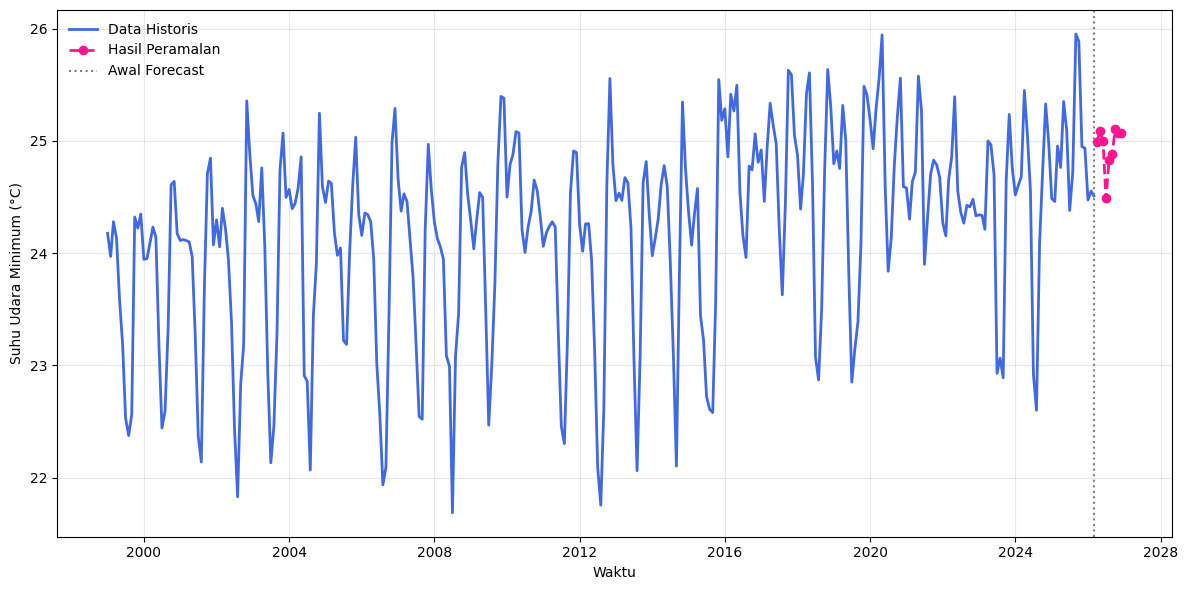

In [ ]:
# Visualisasi Hasil Peramalan
forecast_suhu = pd.DataFrame({
    'tanggal': forecast_data.index,
    'prediksi': forecast_data['Suhu']
})
forecast_suhu.set_index('tanggal', inplace = True)

historical_data_suhu = data[['Suhu']].copy()
combined_suhu = pd.concat([historical_data_suhu, forecast_suhu.rename(columns = {'prediksi': 'Suhu'})])

plt.figure(figsize = (12, 6))

plt.plot(
    historical_data_suhu.index,
    historical_data_suhu['Suhu'],
    label = 'Data Historis',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    forecast_suhu.index,
    forecast_suhu['prediksi'],
    label = 'Hasil Peramalan',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2,
    marker = 'o'
)

plt.axvline(
    x = historical_data_suhu.index[-1],
    color = 'gray',
    linestyle = ':',
    label = 'Awal Forecast'
)

plt.xlabel('Waktu')
plt.ylabel('Suhu Udara Minimum (°C)')

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

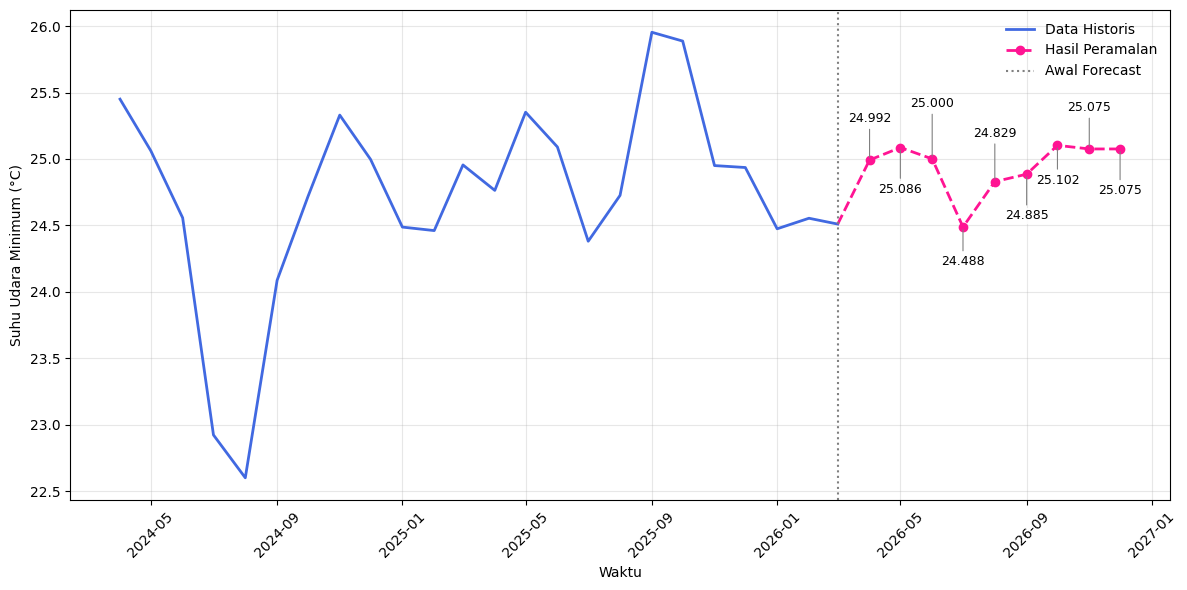

In [ ]:
# Visualisasi Hasil Peramalan
plt.style.use('default')

historical_tail_suhu = data[['Suhu']].tail(24).copy()

forecast_suhu = pd.DataFrame({
    'tanggal': forecast_data.index,
    'prediksi': forecast_data['Suhu']
})
forecast_suhu.set_index('tanggal', inplace = True)

plt.figure(figsize = (12, 6))

plt.plot(
    historical_tail_suhu.index,
    historical_tail_suhu['Suhu'],
    label = 'Data Historis',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    forecast_suhu.index,
    forecast_suhu['prediksi'],
    label = 'Hasil Peramalan',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2,
    marker = 'o'
)

plt.plot(
    [historical_tail_suhu.index[-1], forecast_suhu.index[0]],
    [historical_tail_suhu['Suhu'].iloc[-1], forecast_suhu['prediksi'].iloc[0]],
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

plt.axvline(
    x = historical_tail_suhu.index[-1],
    color = 'gray',
    linestyle = ':',
    label = 'Awal Forecast'
)

offsets = [
    (0, 30),
    (0, -30),
    (0, 40),
    (0, -25),
    (0, 35),
    (0, -30),
    (0, -25),
    (0, 30),
    (0, -30)
]

for (x, y), (dx, dy) in zip(zip(forecast_suhu.index, forecast_suhu['prediksi']), offsets):
    plt.annotate(
        f'{y:.3f}',
        xy = (x, y),
        xytext = (dx, dy),
        textcoords = 'offset points',
        ha = 'center',
        va = 'center',
        fontsize = 9,
        bbox = dict(facecolor = 'white', alpha = 0.85, edgecolor = 'none', pad = 1.2),
        arrowprops = dict(
            arrowstyle = '-',
            color = 'gray',
            lw = 0.8
        )
    )

plt.xlabel('Waktu')
plt.ylabel('Suhu Udara Minimum (°C)')
plt.xticks(rotation = 45)
plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

# TN10p

In [ ]:
# Data Historis
print("Data Historis (5 baris pertama dan terakhir):")
print(data.head())
print("\n...\n")
print(data.tail())
print(f"\nRentang data historis: {data.index[0]} hingga {data.index[-1]}")

Data Historis (5 baris pertama dan terakhir):
                 Suhu  DPM Rata-rata  DPM Maksimum  DPM Minimum
Bulan                                                          
1999-01-01  24.177419    30092.61419      40613.36      9725.40
1999-02-01  23.971429    33898.16893      40363.34      8823.81
1999-03-01  24.280645    32010.34290      40334.69      1194.58
1999-04-01  24.133333    36139.28767      39600.00     19013.41
1999-05-01  23.590323    38292.59323      39589.61     27711.09

...

                 Suhu  DPM Rata-rata  DPM Maksimum  DPM Minimum
Bulan                                                          
2025-11-01  24.950000    30137.76700      42921.25     10830.69
2025-12-01  24.935484    34640.83645      43361.31      6888.92
2026-01-01  24.474194    31986.48355      43070.62      9689.60
2026-02-01  24.553571    34299.91893      42413.89     10800.00
2026-03-01  24.509677    36992.68935      42042.05     25516.61

Rentang data historis: 1999-01-01 00:00:00 hingga 2

In [ ]:
# Membuat DataFrame dari Data Historis
data_historis = data.copy()
data_historis['Suhu'] = data_historis['Suhu']
data_historis['Year'] = data_historis.index.year
data_historis['Month'] = data_historis.index.month
data_historis['Type'] = 'Historis'

print(f"\nJumlah data historis: {len(data_historis)} bulan")


Jumlah data historis: 327 bulan


In [ ]:
# Membuat DataFrame dari Hasil Forecast
data_forecast = forecast_data[['Suhu']].copy()
data_forecast['Year'] = data_forecast.index.year
data_forecast['Month'] = data_forecast.index.month
data_forecast['Type'] = 'Forecast'

print(f"\nJumlah data forecast: {len(data_forecast)} bulan")


Jumlah data forecast: 9 bulan


In [ ]:
# Menggabungkan Data Historis dan Forecast
cols_to_keep = ['Suhu', 'Year', 'Month', 'Type']
data_historis = data_historis[cols_to_keep]
data_forecast = data_forecast[cols_to_keep]

data_gabungan = pd.concat([data_historis, data_forecast], axis = 0)

data_gabungan = data_gabungan.sort_index()

print("Data Gabungan (Historis + Forecast):")
print(f"Total data: {len(data_gabungan)} bulan")
print(f"Rentang waktu: {data_gabungan.index[0]} hingga {data_gabungan.index[-1]}")
print(f"\nBreakdown:")
print(f"- Data historis: {len(data_historis)} bulan")
print(f"- Data forecast: {len(data_forecast)} bulan")
print(f"- Total: {len(data_historis) + len(data_forecast)} bulan")

print("\n5 baris terakhir historis:")
print(data_historis.tail())

print("\n5 baris pertama forecast:")
print(data_forecast.head())

print("\n5 baris terakhir data gabungan:")
print(data_gabungan.tail())

Data Gabungan (Historis + Forecast):
Total data: 336 bulan
Rentang waktu: 1999-01-01 00:00:00 hingga 2026-12-01 00:00:00

Breakdown:
- Data historis: 327 bulan
- Data forecast: 9 bulan
- Total: 336 bulan

5 baris terakhir historis:
                 Suhu  Year  Month      Type
Bulan                                       
2025-11-01  24.950000  2025     11  Historis
2025-12-01  24.935484  2025     12  Historis
2026-01-01  24.474194  2026      1  Historis
2026-02-01  24.553571  2026      2  Historis
2026-03-01  24.509677  2026      3  Historis

5 baris pertama forecast:
                 Suhu  Year  Month      Type
2026-04-01  24.991699  2026      4  Forecast
2026-05-01  25.085724  2026      5  Forecast
2026-06-01  25.000370  2026      6  Forecast
2026-07-01  24.487919  2026      7  Forecast
2026-08-01  24.829117  2026      8  Forecast

5 baris terakhir data gabungan:
                 Suhu  Year  Month      Type
2026-08-01  24.829117  2026      8  Forecast
2026-09-01  24.885220  2026      

In [ ]:
# Persentil ke-10 per Tahun
p10_per_year = (
    data_gabungan
    .groupby('Year')['Suhu']
    .quantile(0.10)
    .reset_index()
    .rename(columns = {'Suhu': 'P10_Suhu'})
)

print("\nPersentil ke-10 (P10) Suhu tiap tahun:")
print(p10_per_year)


Persentil ke-10 (P10) Suhu tiap tahun:
    Year   P10_Suhu
0   1999  22.535366
1   2000  22.651527
2   2001  22.456968
3   2002  22.472366
4   2003  22.506828
5   2004  22.863258
6   2005  23.298387
7   2006  22.141097
8   2007  22.609677
9   2008  23.002387
10  2009  23.057376
11  2010  24.209548
12  2011  22.535591
13  2012  22.143290
14  2013  23.054452
15  2014  23.173871
16  2015  22.620968
17  2016  24.196258
18  2017  24.244323
19  2018  23.117108
20  2019  23.169645
21  2020  24.181269
22  2021  24.304827
23  2022  24.268387
24  2023  22.942581
25  2024  23.038989
26  2025  24.463353
27  2026  24.490095


In [ ]:
# Klasifikasi Bulan < Persentil ke-10
data_p10 = data_gabungan.merge(
    p10_per_year,
    on = 'Year',
    how = 'left'
)

data_p10['Below_P10'] = data_p10['Suhu'] < data_p10['P10_Suhu']

suhu_ekstrem_bawah = data_p10[data_p10['Below_P10']]

print("\nBulan dengan Suhu di Bawah Persentil ke-10 (TN10p):")
print(suhu_ekstrem_bawah[['Suhu', 'Year', 'Month', 'Type', 'P10_Suhu']])

print(f"\nJumlah kejadian suhu < Persentil ke-10: {len(suhu_ekstrem_bawah)} bulan")


Bulan dengan Suhu di Bawah Persentil ke-10 (TN10p):
          Suhu  Year  Month      Type   P10_Suhu
6    22.532258  1999      7  Historis  22.535366
7    22.374194  1999      8  Historis  22.535366
18   22.441935  2000      7  Historis  22.651527
19   22.593548  2000      8  Historis  22.651527
30   22.367742  2001      7  Historis  22.456968
31   22.138710  2001      8  Historis  22.456968
42   22.432258  2002      7  Historis  22.472366
43   21.829032  2002      8  Historis  22.472366
54   22.132258  2003      7  Historis  22.506828
55   22.461290  2003      8  Historis  22.506828
66   22.858065  2004      7  Historis  22.863258
67   22.067742  2004      8  Historis  22.863258
78   23.222581  2005      7  Historis  23.298387
79   23.187097  2005      8  Historis  23.298387
91   21.935484  2006      8  Historis  22.141097
92   22.093333  2006      9  Historis  22.141097
103  22.545161  2007      8  Historis  22.609677
104  22.520000  2007      9  Historis  22.609677
113  22.993333  

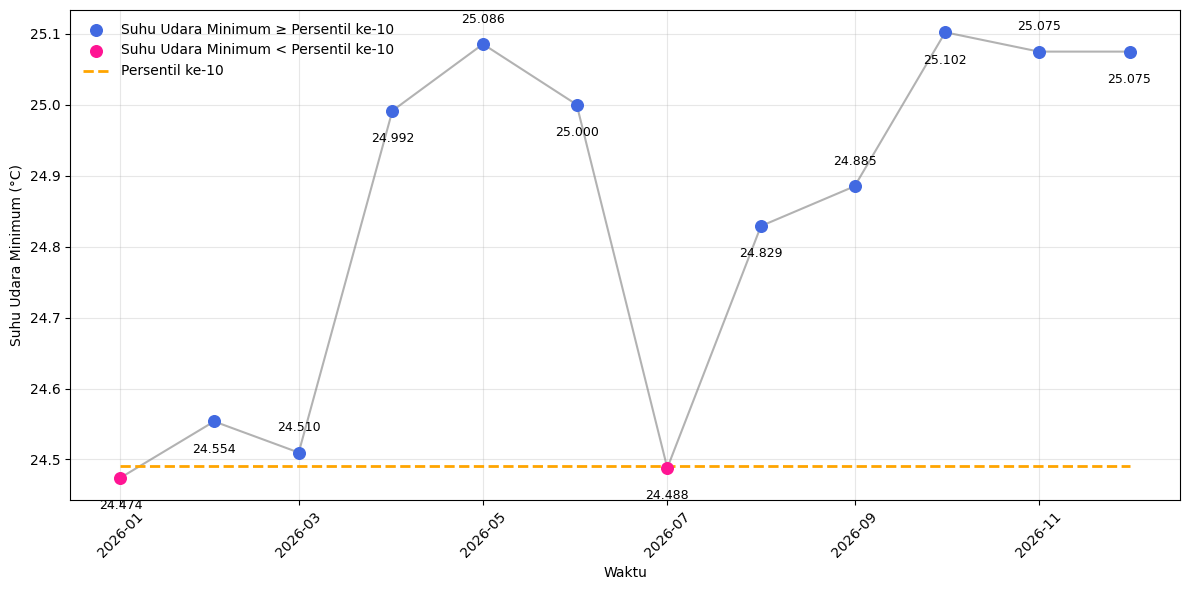

In [ ]:
# Visualisasi Suhu Udara Minimum Tahun 2026 + Peramalan + Persentil ke-10
historical_2026 = data.loc[data.index.year == 2026, ['Suhu']].copy()
historical_2026['Type'] = 'Historis'

forecast_2026 = forecast_data.loc[forecast_data.index.year == 2026, ['Suhu']].copy()
forecast_2026['Type'] = 'Forecast'

data_2026 = pd.concat([historical_2026, forecast_2026], axis = 0)
data_2026 = data_2026.sort_index()

data_2026 = data_2026[~data_2026.index.duplicated(keep = 'first')]

data_2026['P10_Suhu'] = data_2026['Suhu'].quantile(0.10)
data_2026['Below_P10'] = data_2026['Suhu'] < data_2026['P10_Suhu']

data_atas = data_2026[data_2026['Below_P10'] == False]
data_bawah = data_2026[data_2026['Below_P10'] == True]

plt.figure(figsize = (12, 6))

plt.plot(
    data_2026.index,
    data_2026['Suhu'],
    color = 'gray',
    linewidth = 1.5,
    alpha = 0.6
)

plt.scatter(
    data_atas.index,
    data_atas['Suhu'],
    color = 'royalblue',
    s = 70,
    label = 'Suhu Udara Minimum ≥ Persentil ke-10',
    zorder = 3
)

plt.scatter(
    data_bawah.index,
    data_bawah['Suhu'],
    color = 'deeppink',
    s = 70,
    label = 'Suhu Udara Minimum < Persentil ke-10',
    zorder = 3
)

plt.plot(
    data_2026.index,
    data_2026['P10_Suhu'],
    color = 'orange',
    linestyle = '--',
    linewidth = 2,
    label = 'Persentil ke-10'
)

for i, (x, y) in enumerate(zip(data_2026.index, data_2026['Suhu'])):
    if y < data_2026['P10_Suhu'].iloc[0]:
        xytext = (0, -20) if i % 2 == 0 else (0, 18)
    else:
        xytext = (0, 18) if i % 2 == 0 else (0, -20)

    plt.annotate(
        f'{y:.3f}',
        xy = (x, y),
        xytext = xytext,
        textcoords = 'offset points',
        ha = 'center',
        va = 'center',
        fontsize = 9,
        color = 'black'
    )

plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m'))
plt.xticks(rotation = 45)

plt.xlabel('Waktu')
plt.ylabel('Suhu Udara Minimum (°C)')

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()